In [3]:
import pandas as pd
import matplotlib.pyplot as plt


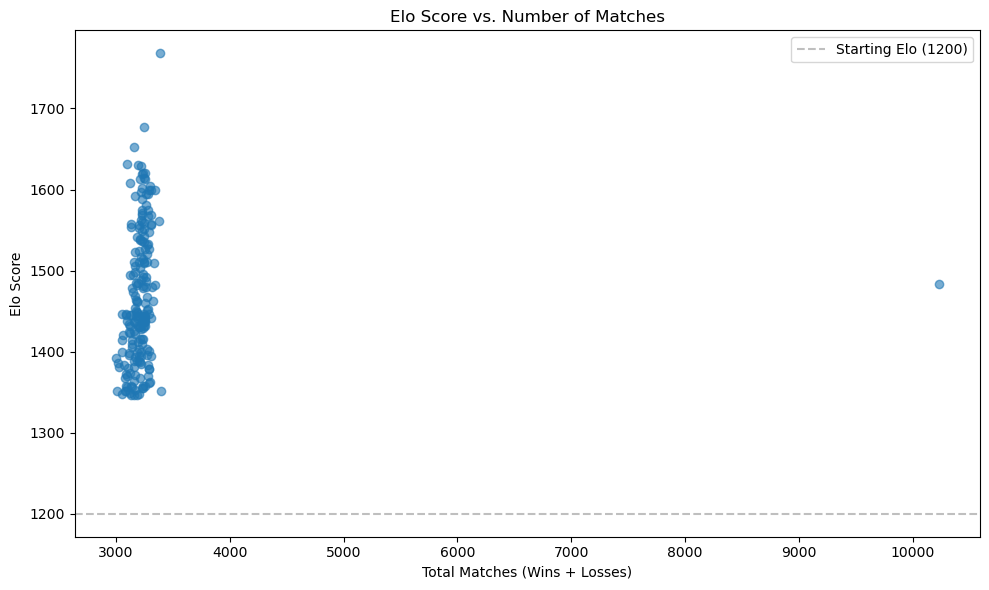

In [6]:
df = pd.read_csv("data/elo_scores.csv")


#Parse wins and losses from the record column (format: "2934W 454L")
df["wins"] = df["record"].str.extract(r'(\d+)W').astype(int)
df["losses"] = df["record"].str.extract(r'(\d+)L').astype(int)
df["total_matches"] = df["wins"] + df["losses"]
df["elo"] = df["elo"].astype(int)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df["total_matches"], df["elo"], alpha=0.6)

ax.set_xlabel("Total Matches (Wins + Losses)")
ax.set_ylabel("Elo Score")
ax.set_title("Elo Score vs. Number of Matches")
ax.axhline(y=1200, color='gray', linestyle='--', alpha=0.5, label="Starting Elo (1200)")
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# See who the outlier is
print(df[df["total_matches"] > 5000])

# Also check win rate - more informative than raw Elo
df["win_rate"] = df["wins"] / df["total_matches"]
print(df[["photo_id", "elo", "total_matches", "win_rate"]].head(20))

          photo_id rank   elo      record  wins  losses  total_matches
76  ART002-E-19180  #77  1483  9481W 749L  9481     749          10230
                      photo_id   elo  total_matches  win_rate
0               ART002-E-15921  1768           3388  0.865998
1     55208327975_1d1e5aa651_o  1677           3250  0.795385
2               ART002-E-15920  1653           3158  0.840722
3     55182918876_b7de1752f8_o  1632           3100  0.751290
4   55193178333_e4a5a133ed_o-1  1630           3193  0.806138
5     55207787628_774eb096db_o  1629           3215  0.829549
6   55187293546_43c21e2ef2_o-1  1620           3252  0.868696
7   55192173787_b8322b1190_o-1  1620           3236  0.785847
8    55186319833_165b4b7852_3k  1619           3228  0.792751
9               ART002-E-20971  1614           3246  0.804991
10              ART002-E-21149  1613           3257  0.780473
11    55208655682_9b9025ca38_o  1613           3207  0.794824
12  55193054741_03c94834b0_o-1  1608           3124 

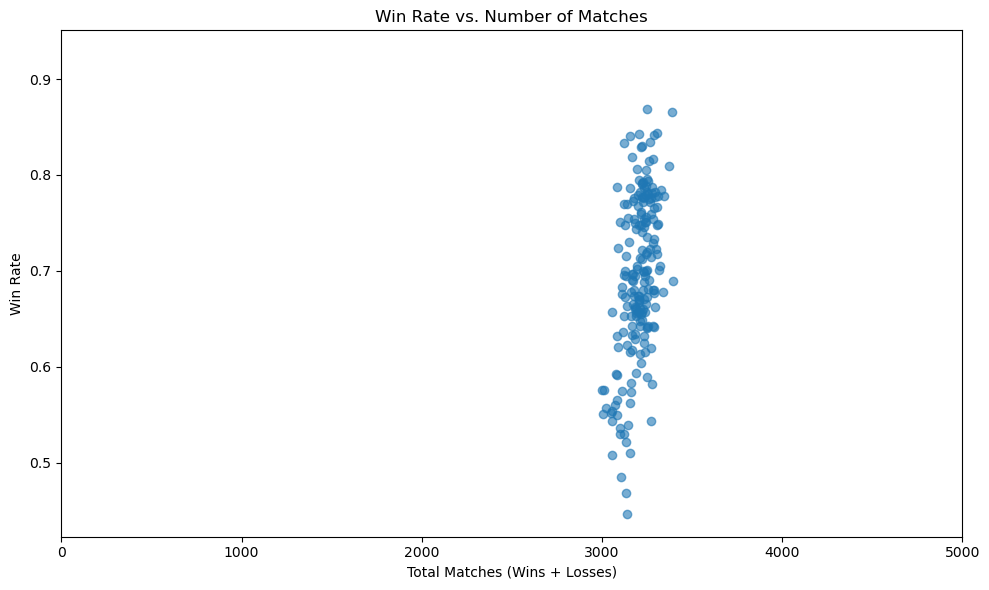

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["total_matches"], df["win_rate"], alpha=0.6)

ax.set_xlim(0, 5000)
ax.set_xlabel("Total Matches (Wins + Losses)")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs. Number of Matches")

plt.tight_layout()
plt.show()

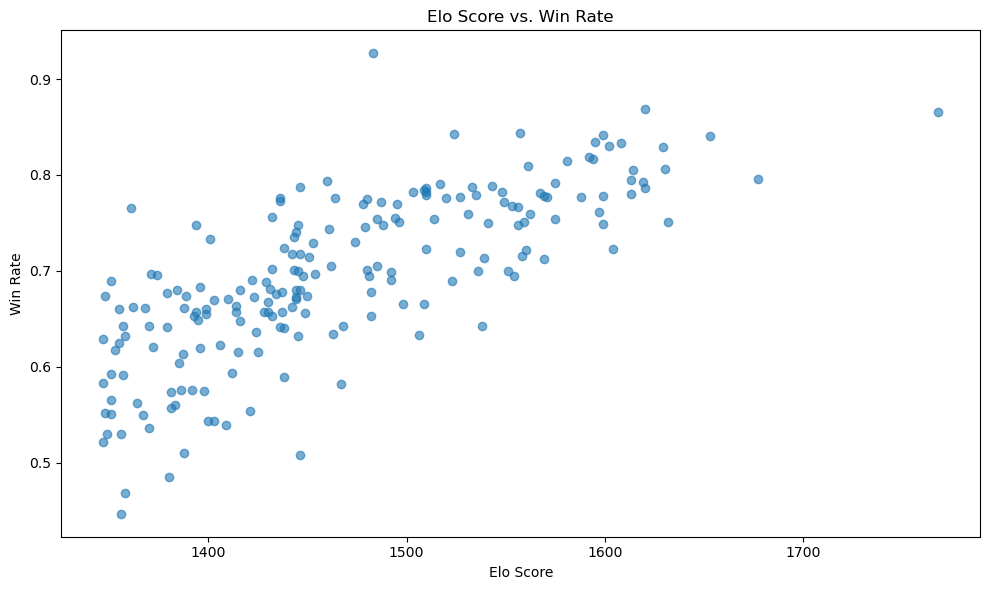

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["elo"], df["win_rate"], alpha=0.6)

ax.set_xlabel("Elo Score")
ax.set_ylabel("Win Rate")
ax.set_title("Elo Score vs. Win Rate")

plt.tight_layout()
plt.show()

In [10]:
correlation = df["elo"].corr(df["win_rate"])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.757


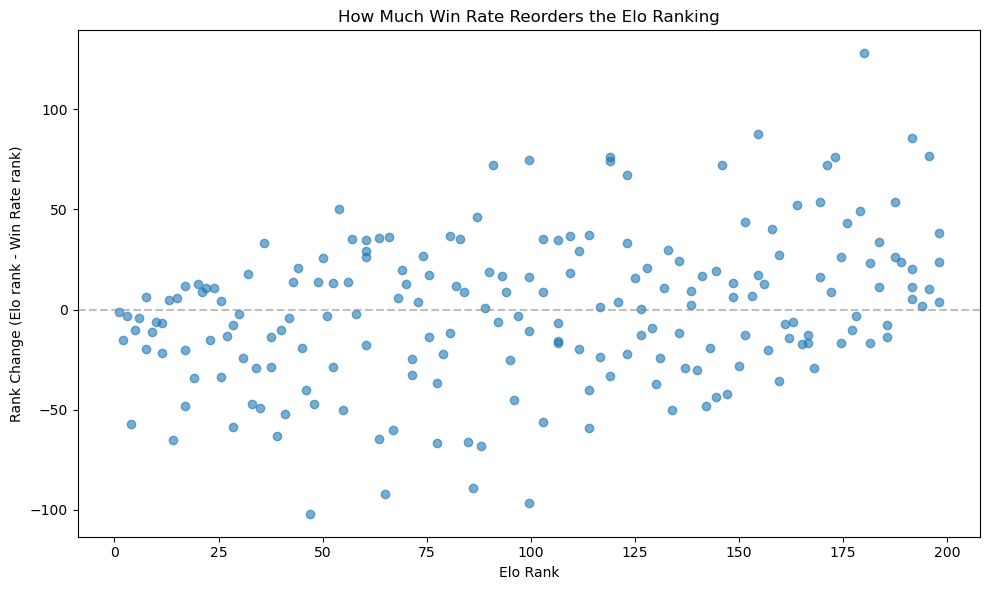

In [14]:
df["elo_rank"] = df["elo"].rank(ascending=False)
df["winrate_rank"] = df["win_rate"].rank(ascending=False)
df["rank_delta"] = df["elo_rank"] - df["winrate_rank"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["elo_rank"], df["rank_delta"], alpha=0.6)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Elo Rank")
ax.set_ylabel("Rank Change (Elo rank - Win Rate rank)")
ax.set_title("How Much Win Rate Reorders the Elo Ranking")

plt.tight_layout()
plt.show()

In [15]:
df["photo_id_short"] = df["photo_id"].str[-8:]  # trim for readability

biggest_movers = df.reindex(df["rank_delta"].abs().nlargest(10).index)
print(biggest_movers[["photo_id", "elo_rank", "winrate_rank", "rank_delta"]].to_string())

                     photo_id  elo_rank  winrate_rank  rank_delta
180            ART002-E-14311     180.0          52.0       128.0
46   55183574561_e9f5de08c2_o      47.0         149.0      -102.0
99   55224193193_4d929dc577_o      99.5         196.0       -96.5
64   55196937384_4d99b6bf96_o      65.0         157.0       -92.0
86   55194598974_0173dc947b_o      86.0         175.0       -89.0
155            ART002-E-25396     154.5          67.0        87.5
192            ART002-E-23310     191.5         106.0        85.5
196             ART002-E-9564     195.5         119.0        76.5
120  55208682757_882e4ffd5c_o     119.0          43.0        76.0
173  55189594357_55ef58f817_o     173.0          97.0        76.0


In [13]:
df = df[df["total_matches"] < 5000]

In [16]:
meta = pd.read_csv("data/metadata.csv")

# Strip .jpg to match elo photo_id format
meta["photo_id"] = meta["file"].str.replace(".jpg", "", regex=False)

# Join on photo_id
merged = df.merge(meta, on="photo_id", how="inner")
print(f"Matched {len(merged)} photos")
merged.head()

Matched 79 photos


,photo_id,rank,elo,record,wins,losses,total_matches,win_rate,elo_rank,winrate_rank,...,file,time,photographer,location,camera,settings,spacecraft,batch,title,flickr_desc
0,55208327975_1d1e5aa651_o,#2,1677,2585W 665L,2585,665,3250,0.795385,2.0,17.0,...,55208327975_1d1e5aa651_o.jpg,2026-04-06 18:41:58,Artemis II Crew,Orion Spacecraft,NIKON D5 + 80.0-400.0 mm f/4.5-5.6,220mm · f/8.0 · 1/1000s · ISO 400,True,1,Earthrise Over the Lunar Far Side,"Earth rises above the Moon's far side horizon,..."
1,55182918876_b7de1752f8_o,#4,1632,2329W 771L,2329,771,3100,0.751290,4.0,61.0,...,55182918876_b7de1752f8_o.jpg,2026-04-01 18:34:40,NASA,Kennedy Space Center,Canon EOS 5DS + EF20mm f/2.8 USM,20mm · f/8.0 · 1/1000s · ISO 100,False,1,Artemis II Launch (NHQ202604010224),NASA’s Space Launch System rocket carrying the...
2,55207787628_774eb096db_o,#6,1629,2667W 548L,2667,548,3215,0.829549,6.0,10.0,...,55207787628_774eb096db_o.jpg,2026-04-06 20:40:54,Artemis II Crew,Orion Spacecraft,HERO4 Black,3mm · f/2.8 · 5s · ISO 800,True,1,Solar Eclipse from the Far Side,The Sun is fully eclipsed by the Moon as seen ...
3,55186319833_165b4b7852_3k,#9,1619,2559W 669L,2559,669,3228,0.792751,9.0,20.0,...,55186319833_165b4b7852_3k.jpg,2026-04-01 18:34:40,NASA,Kennedy Space Center,Unknown,Unknown,False,1,SLS Twin Boosters Ignite,The twin solid rocket boosters of NASA's Space...
4,55208655682_9b9025ca38_o,#12,1613,2549W 658L,2549,658,3207,0.794824,11.5,18.0,...,55208655682_9b9025ca38_o.jpg,2026-04-06 18:40:29,Artemis II Crew,Orion Spacecraft,NIKON D5 + 80.0-400.0 mm f/4.5-5.6,140mm · f/7.1 · 1/800s · ISO 400,True,1,Earthrise Behind the Lunar Limb,A crescent Earth peeks out from behind the Moo...


In [17]:
# Camera type vs win rate
print("Win rate by camera:")
print(merged.groupby("camera")["win_rate"].agg(["mean", "count"]).sort_values("mean", ascending=False))

Win rate by camera:
                                                mean  count
camera                                                     
Canon EOS 6D + EF20mm f/2.8 USM             0.800493      2
Unknown                                     0.792751      1
Canon EOS 5DS + EF20mm f/2.8 USM            0.751290      1
HERO4 Black                                 0.721207      7
Canon EOS 5D Mark II + EF50mm f/1.4 USM     0.712469      1
NIKON Z 9 + 35mm f/2D                       0.704191      7
NIKON D5 + 35.0 mm f/2.0                    0.696941      1
Canon EOS 7D Mark II + EF20mm f/2.8 USM     0.694223      1
NIKON Z 9 + NIKKOR Z 400mm f/2.8 TC VR S    0.673797      1
NIKON D5 + 80.0-400.0 mm f/4.5-5.6          0.656837     32
NIKON Z 9 + VR 800mm f/5.6E                 0.640418      1
Canon EOS 5D Mark III + EF135mm f/2L USM    0.633794      1
NIKON D5 + 14.0-24.0 mm f/2.8               0.600830      8
NIKON D5 + 70.0-200.0 mm f/2.8              0.592532      1
LEICA M MONOCHROM (T

In [18]:
# Spacecraft flag vs win rate  
print("\nWin rate by spacecraft flag:")
print(merged.groupby("spacecraft")["win_rate"].agg(["mean", "count"]))


Win rate by spacecraft flag:
                mean  count
spacecraft                 
False       0.635104     29
True        0.656223     50


In [19]:
# Batch vs win rate
print("\nWin rate by batch:")
print(merged.groupby("batch")["win_rate"].agg(["mean", "count"]).sort_values("mean", ascending=False))


Win rate by batch:
           mean  count
batch                 
1      0.651296     77
0      0.539708      2
